In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Teaching Materials/ML/Datasets/MBA_Admission.csv')

In [ ]:
df.head()

,GPA,GMAT,Decision
0,2.96,596,admit
1,3.14,473,admit
2,3.22,482,admit
3,3.29,527,admit
4,3.69,505,admit


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   GPA       85 non-null     float64
 1   GMAT      85 non-null     int64  
 2   Decision  85 non-null     object 
dtypes: float64(1), int64(1), object(1)
memory usage: 2.1+ KB


In [ ]:
df.describe()

,GPA,GMAT
count,85.000000,85.000000
mean,2.974588,488.447059
std,0.428995,81.522347
min,2.130000,313.000000
25%,2.600000,425.000000
50%,3.010000,482.000000
75%,3.300000,538.000000
max,3.800000,693.000000


In [ ]:
df.isnull().sum()

,0
GPA,0
GMAT,0
Decision,0


In [ ]:
df.columns

Index(['GPA', 'GMAT', 'Decision'], dtype='object')

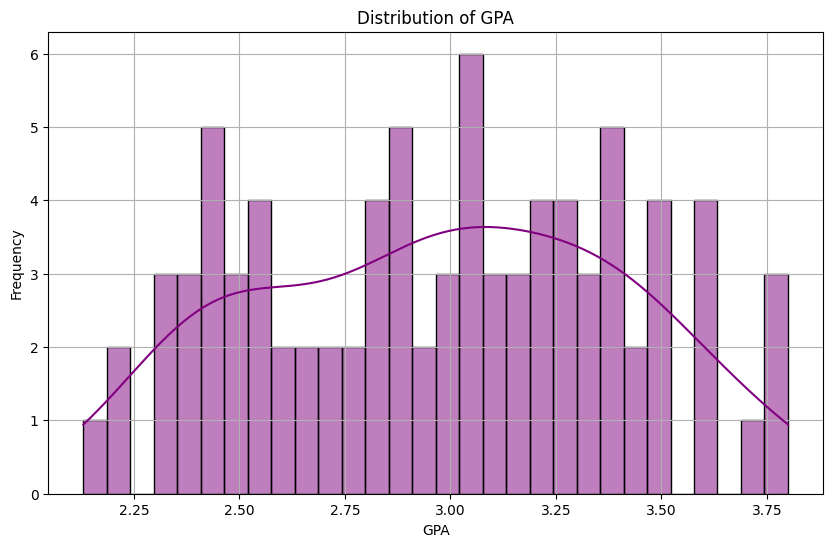

In [ ]:
gpa = df['GPA']

plt.figure(figsize=(10, 6))
sns.histplot(gpa, bins=30, kde=True, color='purple')
plt.title('Distribution of GPA')
plt.xlabel('GPA')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

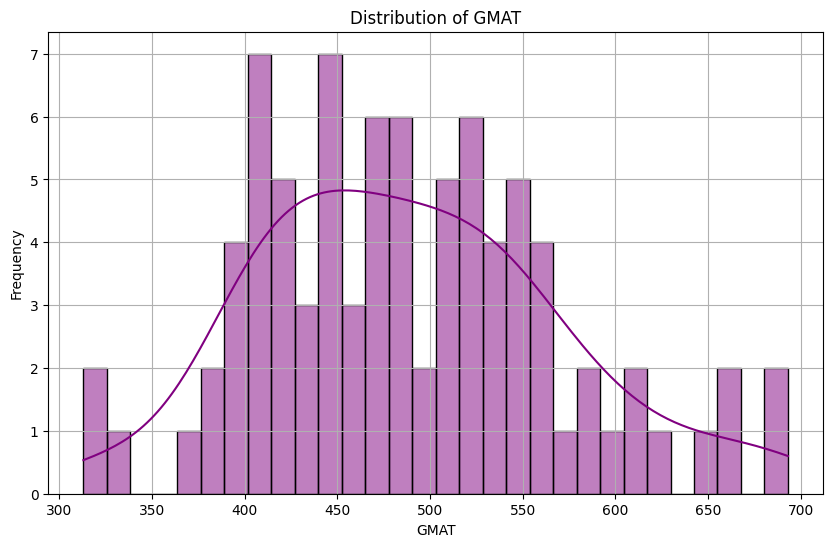

In [ ]:
gmat = df['GMAT']

plt.figure(figsize=(10, 6))
sns.histplot(gmat, bins=30, kde=True, color='purple')
plt.title('Distribution of GMAT')
plt.xlabel('GMAT')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [ ]:
y = df['Decision']
X = df.drop(['Decision'], axis = 1)

In [ ]:
y

,Decision
0,admit
1,admit
2,admit
3,admit
4,admit
...,...
80,border
81,border
82,border
83,border


In [ ]:
X

,GPA,GMAT
0,2.96,596
1,3.14,473
2,3.22,482
3,3.29,527
4,3.69,505
...,...,...
80,3.05,399
81,2.85,483
82,3.01,453
83,3.03,414


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # scaling numerics

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [ ]:
X_train.shape

(68, 2)

In [ ]:
X_test.shape

(17, 2)

In [ ]:
y_train.shape

(68,)

In [ ]:
y_test.shape

(17,)

In [ ]:
scaler = StandardScaler()

scaler.fit(X_train)

StandardScaler()

In [ ]:
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
y.unique()

array(['admit', 'notadmit', 'border'], dtype=object)

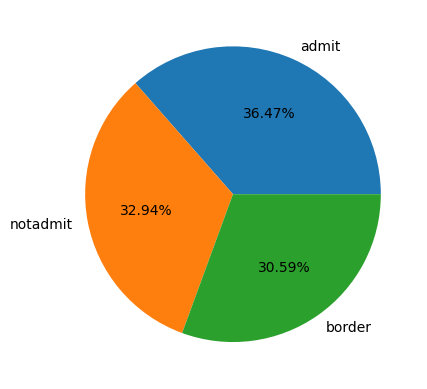

In [ ]:
label_counts = df['Decision'].value_counts()
plt.pie(label_counts, labels = ['admit', 'notadmit', 'border'], autopct = '%.2f%%')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
models = {'rfc': RandomForestClassifier(n_estimators = 100, random_state = 42),
          'knc': KNeighborsClassifier(n_neighbors=5)}

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
def show_confusion_matrix(test, prediction):
  conf_matrix = confusion_matrix(test, prediction)
  plt.figure(figsize=(8,6))
  sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['admit', 'notadmit', 'border'], yticklabels=['admit', 'notadmit', 'border'])
  plt.xlabel('Predictions')
  plt.ylabel('Actual')
  plt.title('Confusion Matrix')
  plt.show()

Model: rfc
Accuracy: 1.0

Confusion Matrix


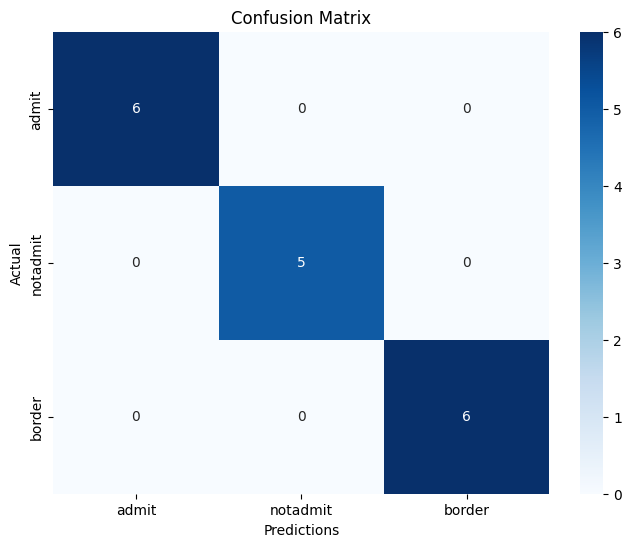


Classification Report

               precision    recall  f1-score   support

       admit       1.00      1.00      1.00         6
      border       1.00      1.00      1.00         5
    notadmit       1.00      1.00      1.00         6

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17

Model: knc
Accuracy: 1.0

Confusion Matrix


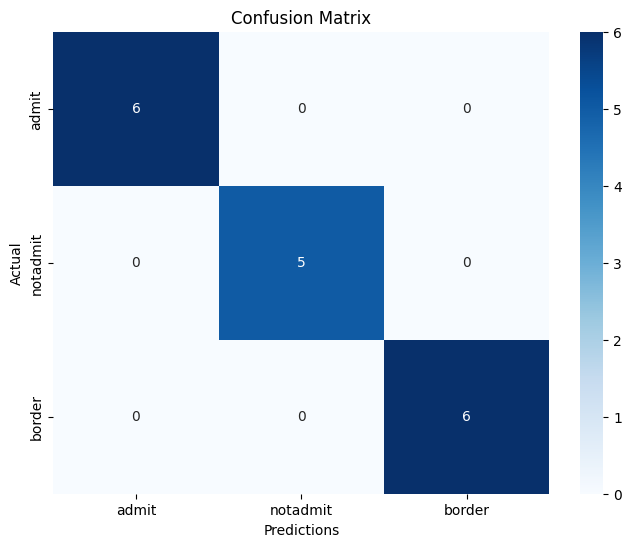


Classification Report

               precision    recall  f1-score   support

       admit       1.00      1.00      1.00         6
      border       1.00      1.00      1.00         5
    notadmit       1.00      1.00      1.00         6

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17



In [ ]:
for name, model in models.items():
  print('Model:', name)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  print('Accuracy:', accuracy_score(y_test, y_pred))
  print('\nConfusion Matrix')
  show_confusion_matrix(y_test, y_pred)
  print('\nClassification Report')
  print('\n', classification_report(y_test, y_pred))